# Model comparison — pdfplumber

Three models on the same 10 Data Management Plans, the same extraction, and the
same prompt. Text-block classification into five classes.

Because stage 1 is cached per extractor, every model here received **identical
blocks** — so any difference below is the model.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.annotation_rules import load_method_new
from dmpbridge.evaluation.annotation_rules import resolve_new_gt_path
from dmpbridge.evaluation.evaluate import (
    LABELS, _confusion_from_match, _match_structured, compute_f1_rows,
    extract_gold, load_method, micro_prf1, resolve_old_gt_path,
)

MODELS, EXTRACTOR, SAMPLES = ['llama3.1:8b', 'gemma4:e4b', 'llama3.3:70b'], 'pdfplumber', range(1, 11)

# Reference categorical palette, slots 1-3 — one hue per model, held
# constant in every chart below.
COLOURS = ['#2a78d6', '#eb6834', '#1baf7a']
INK, MUTED, SURFACE, GRID = '#0b0b0b', '#52514e', '#fcfcfb', '#e6e6e2'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.titleweight': 'bold',
    'axes.grid': False, 'legend.frameon': False,
})
pd.set_option('display.max_colwidth', 60)

available, CONF = [], {}
for m in MODELS:
    tag = P.make_tag(m, EXTRACTOR)
    if not all(P.structured_path(tag, n).exists() for n in SAMPLES):
        print('not yet run, skipped:', m)
        continue
    available.append(m)
    CONF[m] = {'A': load_method(tag, exclude=[])[1],
               'B': load_method_new(tag, exclude=[])[1]}

COLOUR = dict(zip(available, COLOURS))
print('comparing:', ', '.join(available))


not yet run, skipped: llama3.3:70b
comparing: llama3.1:8b, gemma4:e4b


## 1. Metrics

Each predicted block is matched to a reference block by token overlap, giving three
possible outcomes:

| | |
|---|---|
| **TP** &nbsp;true positive | matched to a reference block, with the same class |
| **FP** &nbsp;false positive | predicted with the wrong class, or with no reference counterpart |
| **FN** &nbsp;false negative | a reference block not matched, or matched with the wrong class |

```
precision  =  TP / (TP + FP)
recall     =  TP / (TP + FN)
f1-score   =  2 * precision * recall / (precision + recall)
```

Precision falls when the model over-generates; recall falls when it under-generates.
The f1-score is their harmonic mean, so it stays low unless both are high.

### The two paths

| | prediction scored | reference |
|---|---|---|
| **Path A** | stage 3, the model's structured output as produced | the original annotation |
| **Path B** | stage 4, the same output after the annotation rules are applied | the revised annotation |

Compare models **down a column**, never Path A against Path B — the two paths score
different numbers of items.


In [2]:
rows = []
for m in available:
    a, b = micro_prf1(CONF[m]['A']), micro_prf1(CONF[m]['B'])
    rows.append({'model': m,
                 'precision': a['precision'], 'recall': a['recall'],
                 'Path A f1': a['f1'], 'Path B f1': b['f1'],
                 'TP': a['tp'], 'FP': a['fp'], 'FN': a['fn']})

head = pd.DataFrame(rows).set_index('model')
display(head.style
        .background_gradient(cmap='Greens', subset=['Path A f1', 'Path B f1'])
        .format({'precision': '{:.3f}', 'recall': '{:.3f}',
                 'Path A f1': '{:.3f}', 'Path B f1': '{:.3f}'}))


,precision,recall,Path A f1,Path B f1,TP,FP,FN
model,,,,,,,
llama3.1:8b,0.198,0.606,0.298,0.323,80,325,52
gemma4:e4b,0.617,0.780,0.689,0.692,103,64,29


## 2. Classification report

Per class, every model side by side. Support is the number of reference blocks of
that class and is the same for all models, so the scores are directly comparable.

**These figures cover all 10 documents at once.** The counts are pooled first and the
score computed from the total — not worked out per document and then averaged. A long
document therefore carries more weight than a short one, which is what you want when
the question is how the model performs on this corpus.


In [3]:
for path, name in (('A', 'Path A — model output as produced'),
                   ('B', 'Path B — after the annotation rules')):
    per = {m: compute_f1_rows(CONF[m][path]).set_index('label') for m in available}
    tbl = pd.DataFrame({m: per[m]['f1'] for m in available})
    tbl.insert(0, 'support', per[available[0]]['support'].astype(int))
    tbl.loc['micro avg'] = [tbl['support'].sum()] + \
                           [micro_prf1(CONF[m][path])['f1'] for m in available]
    tbl.index.name = 'f1-score'
    display(tbl.style
            .set_caption(name)
            .set_table_styles([{'selector': 'caption',
                                'props': [('caption-side', 'top'),
                                          ('font-size', '110%'),
                                          ('font-weight', '600'),
                                          ('text-align', 'left'),
                                          ('padding-bottom', '6px'),
                                          ('color', INK)]}])
            .background_gradient(cmap='Greens', subset=available, axis=None)
            .format({m: '{:.3f}' for m in available} | {'support': '{:.0f}'}))
    print()


,support,llama3.1:8b,gemma4:e4b
f1-score,,,
title,10,1.000,0.824
section.title,43,0.569,0.760
section.description,8,0.286,0.667
question.text,16,0.014,0.391
answer.text,55,0.275,0.732
micro avg,132,0.298,0.689


,support,llama3.1:8b,gemma4:e4b
f1-score,,,
title,10,1.000,0.824
section.title,43,0.569,0.760
section.description,8,0.286,0.667
question.text,56,0.179,0.581
answer.text,55,0.275,0.732
micro avg,172,0.323,0.692


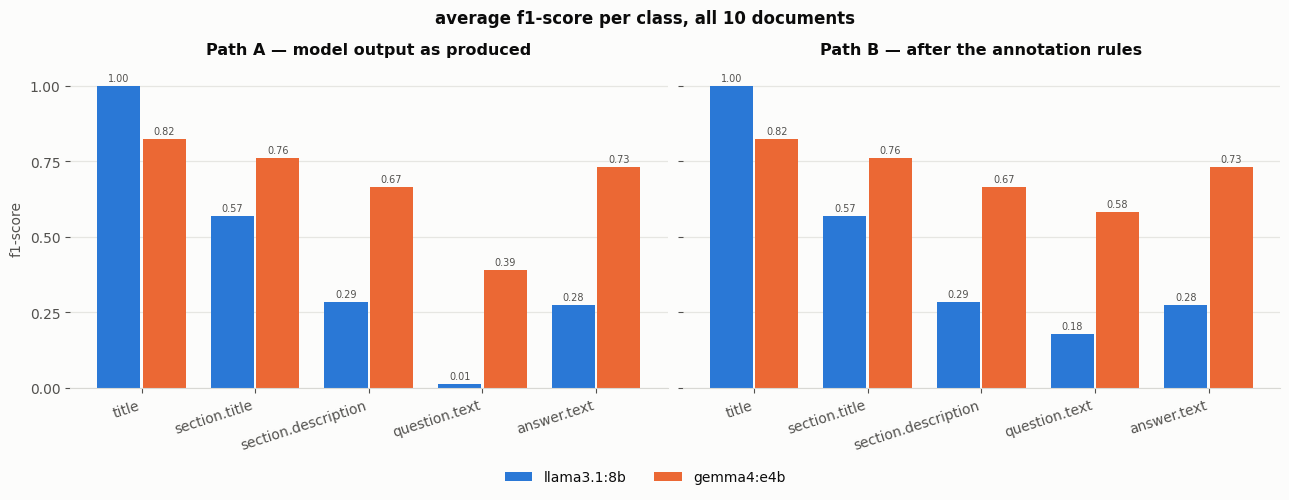

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), sharey=True)
w = 0.8 / max(len(available), 1)

for ax, path, name in zip(axes, ('A', 'B'), ('Path A', 'Path B')):
    per = {m: compute_f1_rows(CONF[m][path]).set_index('label') for m in available}
    x = np.arange(len(LABELS))
    for k, m in enumerate(available):
        vals = [per[m]['f1'].get(l, 0) for l in LABELS]
        bars = ax.bar(x + (k - (len(available) - 1) / 2) * w, vals,
                      width=w - 0.02, color=COLOUR[m], label=m)
        ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7, color=MUTED)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, rotation=18, ha='right')
    ax.set_ylim(0, 1.06)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_title('Path A — model output as produced' if path == 'A'
                 else 'Path B — after the annotation rules', pad=10)
    ax.grid(axis='y', color=GRID, linewidth=0.9)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)

axes[0].set_ylabel('f1-score')
plt.tight_layout()

# Legend below the panels: at the top it collides with the two subplot
# titles, which are long enough to reach the middle of the figure.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(available), loc='upper center',
           bbox_to_anchor=(0.5, 0.02))
fig.suptitle('average f1-score per class, all 10 documents',
             fontweight='bold', y=1.04)
plt.show()


The label to watch is `question.text`. It is where the models separate most, and it
is the one the annotation rules target — compare its Path A and Path B bars for each
model to see how much the rules recover.


In [5]:
def per_document_f1(model, path):
    """f1 for each class in each document, scored independently."""
    tag = P.make_tag(model, EXTRACTOR)
    rows = []
    for n in SAMPLES:
        if path == 'A':
            gold = extract_gold(resolve_old_gt_path(n))
            rec, ng = _match_structured(P.structured_path(tag, n), gold)
        else:
            gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
            rec, ng = _match_structured(P.final_path(tag, n), gold,
                                        dedup_question_title=False)
        f1s = compute_f1_rows(_confusion_from_match(rec, ng)).set_index('label')
        for lab in LABELS:
            if lab in f1s.index and f1s.loc[lab, 'support'] > 0:
                rows.append({'sample': n, 'label': lab, 'f1': f1s.loc[lab, 'f1']})
    return pd.DataFrame(rows)


for path, name in (('A', 'Path A'), ('B', 'Path B')):
    tbl = pd.DataFrame(index=LABELS)
    for m in available:
        d = per_document_f1(m, path)
        tbl[m] = d.groupby('label')['f1'].mean()
        if m == available[0]:
            tbl.insert(0, 'documents', d.groupby('label')['f1'].count())
    tbl.index.name = 'mean f1 per document'
    display(tbl.style
            .set_caption(f'{name} — each document scored separately, then averaged')
            .set_table_styles([{'selector': 'caption',
                                'props': [('caption-side', 'top'),
                                          ('font-size', '110%'),
                                          ('font-weight', '600'),
                                          ('text-align', 'left'),
                                          ('padding-bottom', '6px'),
                                          ('color', INK)]}])
            .background_gradient(cmap='Greens', subset=available, axis=None)
            .format({m: '{:.3f}' for m in available} | {'documents': '{:.0f}'}))
    print()


,documents,llama3.1:8b,gemma4:e4b
mean f1 per document,,,
title,10,1.000,0.700
section.title,8,0.573,0.759
section.description,2,0.376,1.000
question.text,2,0.083,0.500
answer.text,10,0.288,0.751


,documents,llama3.1:8b,gemma4:e4b
mean f1 per document,,,
title,10,1.000,0.700
section.title,8,0.573,0.759
section.description,2,0.376,1.000
question.text,10,0.198,0.636
answer.text,10,0.288,0.751


**Where the two disagree, the reason is document size.** A class that the model handles
well in several small documents and badly in one large one scores higher here than in
the pooled table, because the large document no longer dominates.

Quote whichever you like, but say which — and do not mix them in the same comparison.


## 3. Confusion matrices

Rows are the true class, columns the predicted class; the outlined diagonal is
agreement. All panels share one colour scale, so a cell of a given darkness means
the same count in every model.

**Top row is Path A, bottom row is Path B**, so reading down a column shows what the
annotation rules changed for that model. Blocks with no counterpart on either side
cannot appear in a matrix, which is why a row may not sum to that class's support.


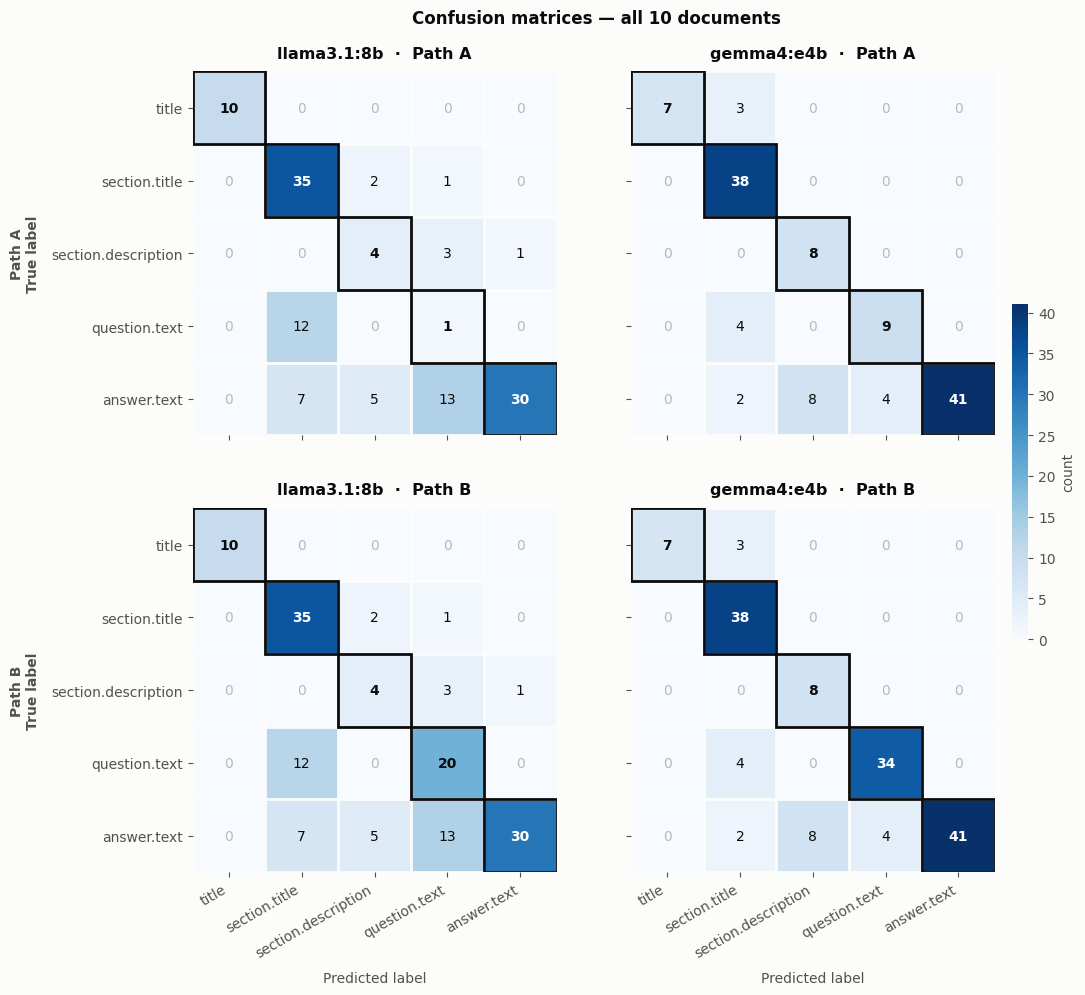

In [6]:
def build_cm(conf):
    cm = np.zeros((len(LABELS), len(LABELS)), dtype=int)
    for i, t in enumerate(LABELS):
        for j, p in enumerate(LABELS):
            cm[i, j] = conf.get(t, {}).get(p, 0)
    return cm


cms = {(m, path): build_cm(CONF[m][path])
       for m in available for path in ('A', 'B')}
vmax = max(cm.max() for cm in cms.values())   # one scale for every panel

ncol = max(len(available), 1)
fig, axes = plt.subplots(2, ncol, figsize=(5.4 * ncol, 10.4),
                         squeeze=False)

for r, path in enumerate(('A', 'B')):
    for c, m in enumerate(available):
        ax, cm = axes[r][c], cms[(m, path)]
        im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=vmax)
        for i in range(len(LABELS)):
            for j in range(len(LABELS)):
                v = cm[i, j]
                ax.text(j, i, v, ha='center', va='center', fontsize=10,
                        fontweight='bold' if i == j else 'normal',
                        color='#b9b9b4' if v == 0
                        else ('white' if v > vmax * 0.55 else INK))
        ax.set_xticks(range(len(LABELS)))
        ax.set_yticks(range(len(LABELS)))
        # Class names only on the outer edges, or six panels of labels
        # crowd out the counts they are meant to explain.
        ax.set_xticklabels(LABELS if r == 1 else [], rotation=30, ha='right')
        ax.set_yticklabels(LABELS if c == 0 else [])
        if r == 1:
            ax.set_xlabel('Predicted label', labelpad=8)
        if c == 0:
            ax.set_ylabel(f'Path {path}\nTrue label', labelpad=8,
                          fontweight='bold')
        ax.set_title(f'{m}  ·  Path {path}', pad=10)
        ax.set_xticks(np.arange(-.5, len(LABELS), 1), minor=True)
        ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
        ax.grid(which='minor', color=SURFACE, linewidth=2)
        ax.tick_params(which='minor', length=0)
        for k in range(len(LABELS)):
            ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                                       edgecolor=INK, linewidth=2.0, zorder=5))
        for spine in ax.spines.values():
            spine.set_visible(False)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02,
             label='count').outline.set_visible(False)
fig.suptitle('Confusion matrices — all 10 documents',
             fontweight='bold', y=0.94)
plt.show()


**Across a row** — find the same cell in each model and compare. The `question.text`
row is the most informative: the count sitting in the `section.title` column is the
lettered-sub-item confusion, and its size separates the models more clearly than any
headline score does.

**Down a column** — the same model before and after the annotation rules. The rules
only ever write to `question.text`, so every other cell should be identical between
the two rows. Anything else moving would mean the rules had overreached.
